<a href="https://colab.research.google.com/github/Linzdhx/Mineria_datos_covid/blob/Data-realista/Examen_Data_real.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Global Inflation Dynamics Post-COVID (2020-2024) [Conjunto de datos]. Kaggle. https://www.kaggle.com/datasets/ssssws/global-inflation-dynamics-post-covid-20202024.

**Repositorio** de GIthub: https://github.com/Linzdhx/Mineria_datos_covid/blob/main/Mineria_datos_covid.ipynb

Looker studio: https://datastudio.google.com/u/0/reporting/c1abea37-6196-4b36-94d7-47770e2d7f5a/page/Ug01F/edit

# 1. Configuración Inicial y Carga de Datos

Esta sección se encarga de importar las librerías necesarias para el análisis y configurar las opciones de visualización de pandas para mostrar todas las columnas y filas de los DataFrames, lo cual es útil para una inspección completa de los datos.

In [ ]:
#importamos librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
dr = pd.read_csv("/content/data_realista.csv")
# Ver los primeros registros
print("Primeras 5 filas:")
display(dr.head())

Primeras 5 filas:


,country,date,inflation_rate,unemployment_rate,oil_price,supply_chain_index
0,USA,2020-01,0.4,3.5,63.60,0.06
1,USA,2020-02,0.3,3.5,55.54,1.30
2,USA,2020-03,-0.2,4.4,32.01,2.67
3,USA,2020-04,-0.7,14.7,NaN,3.39
4,USA,2020-05,0.0,13.2,29.12,2.58


In [ ]:
df = pd.read_csv("/content/covid.csv")
# Ver los primeros registros
print("Primeras 5 filas:")
display(dr.head())

Primeras 5 filas:


,country,date,inflation_rate,unemployment_rate,oil_price,supply_chain_index
0,USA,2020-01,0.4,3.5,63.60,0.06
1,USA,2020-02,0.3,3.5,55.54,1.30
2,USA,2020-03,-0.2,4.4,32.01,2.67
3,USA,2020-04,-0.7,14.7,NaN,3.39
4,USA,2020-05,0.0,13.2,29.12,2.58


In [ ]:
dr.shape

(1200, 6)

In [ ]:
# Información general: tipos de datos y si hay valores nulos
for feature in dr.columns:
    print('Total de valores nulos de', feature, '=', dr[feature].isna().sum())

Total de valores nulos de country = 0
Total de valores nulos de date = 0
Total de valores nulos de inflation_rate = 359
Total de valores nulos de unemployment_rate = 815
Total de valores nulos de oil_price = 260
Total de valores nulos de supply_chain_index = 480


In [ ]:
# Información general: tipos de datos y si hay valores nulos
for feature in df.columns:
    print('Total de valores nulos de', feature, '=', df[feature].isna().sum())

Total de valores nulos de country = 0
Total de valores nulos de date = 0
Total de valores nulos de inflation_rate = 0
Total de valores nulos de interest_rate = 0
Total de valores nulos de oil_price = 0
Total de valores nulos de gdp_growth = 0
Total de valores nulos de unemployment_rate = 0
Total de valores nulos de money_supply_m2 = 0
Total de valores nulos de exchange_rate_usd = 0
Total de valores nulos de food_price_index = 0
Total de valores nulos de supply_chain_index = 0


In [ ]:
dr.describe()

,inflation_rate,unemployment_rate,oil_price,supply_chain_index
count,841.000000,385.000000,940.000000,720.000000
mean,12.659715,18.076545,69.772340,2.660000
std,119.907999,145.765097,16.641207,1.354323
min,-3.440000,2.000000,29.120000,0.060000
25%,1.700000,3.500000,62.280000,1.445000
50%,3.300000,5.400000,74.880000,2.705000
75%,5.880000,8.280000,82.500000,4.032500
max,2019.000000,2026.000000,93.650000,4.470000


In [ ]:
df.describe()

,inflation_rate,interest_rate,oil_price,gdp_growth,unemployment_rate,money_supply_m2,exchange_rate_usd,food_price_index,supply_chain_index
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,4.175859,2.559960,75.026843,2.476658,5.514667,11947.973270,46.908610,119.597836,1.939958
std,1.463516,1.856475,24.380590,2.156974,1.199608,2744.008662,30.259072,17.118195,0.912450
min,-1.999003,-2.810000,22.640000,-4.580000,2.000000,3858.000000,2.340000,70.770000,1.000000
25%,3.173408,1.190000,62.860000,1.090000,4.710000,10060.000000,22.610000,107.180000,1.240000
50%,4.226506,2.590000,75.200000,2.520000,5.500000,11788.000000,42.360000,119.830000,1.670000
75%,5.202572,3.940000,85.680000,3.940000,6.340000,13690.000000,73.310000,132.420000,2.270000
max,9.634656,8.130000,153.770000,10.090000,9.140000,21241.000000,104.950000,165.300000,4.880000


In [ ]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

In [ ]:
dr_knn = dr.copy()

numerical_cols = ['inflation_rate', 'unemployment_rate', 'oil_price', 'supply_chain_index']
# Inicializamos el estandarizador
scaler = StandardScaler()

# Ajustamos y transformamos solo las columnas numéricas
dr_knn[numerical_cols] = scaler.fit_transform(dr_knn[numerical_cols])

In [ ]:
# Inicializamos el KNNImputer. Puedes ajustar el número de vecinos (n_neighbors).
knn_imputer = KNNImputer(n_neighbors=5)

# Aplicamos la imputación solo a las columnas numéricas que fueron estandarizadas
dr_knn[numerical_cols] = knn_imputer.fit_transform(dr_knn[numerical_cols])

In [ ]:
# Deshacemos la estandarización para que los datos vuelvan a su escala original
dr_knn[numerical_cols] = scaler.inverse_transform(dr_knn[numerical_cols])

In [ ]:
print("Valores nulos después de la imputación KNN:")
for feature in dr_knn.columns:
    print(f'Total de valores nulos de {feature} = {dr_knn[feature].isna().sum()}')

Valores nulos después de la imputación KNN:
Total de valores nulos de country = 0
Total de valores nulos de date = 0
Total de valores nulos de inflation_rate = 0
Total de valores nulos de unemployment_rate = 0
Total de valores nulos de oil_price = 0
Total de valores nulos de supply_chain_index = 0


In [ ]:
display(dr_knn.describe())

,inflation_rate,unemployment_rate,oil_price,supply_chain_index
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,16.262697,19.532350,70.377458,2.824970
std,110.663262,101.242889,16.552318,1.254805
min,-3.440000,2.000000,29.120000,0.060000
25%,2.100000,4.807500,62.280000,1.800000
50%,3.706000,6.082000,75.630000,2.722000
75%,6.202500,8.158000,82.250000,4.200000
max,2019.000000,2026.000000,93.650000,4.470000


# 2. Matriz de correlacion


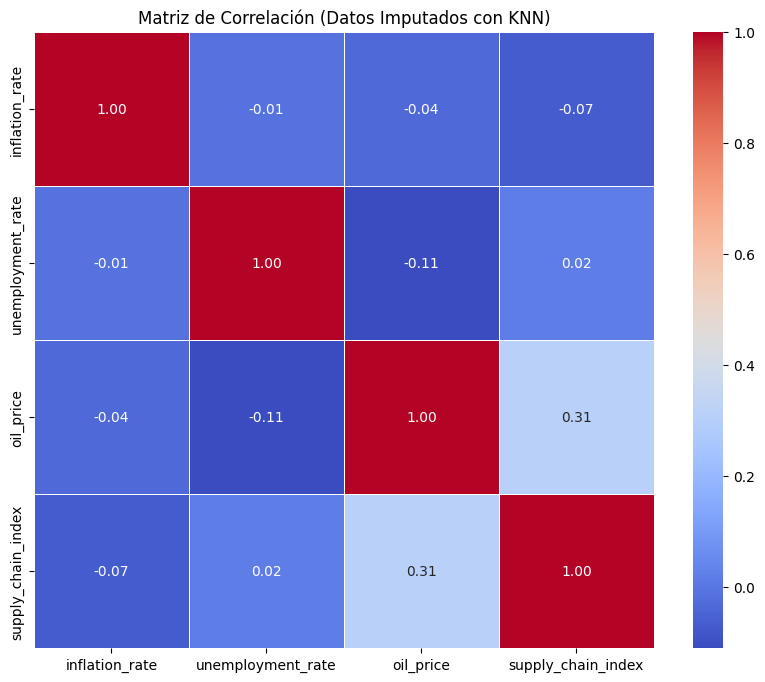

In [ ]:
# Calculamos la matriz de correlación solo para las columnas numéricas de dr_knn
corr_matrix = dr_knn[numerical_cols].corr()

# Configuramos el estilo de la visualización
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación (Datos Imputados con KNN)')
plt.show()

Petróleo e Índice de Suministros (0.42) Es una correlación positiva. Significa que cuando el precio del petróleo sube, la cadena de suministro también tienden a aumentar.

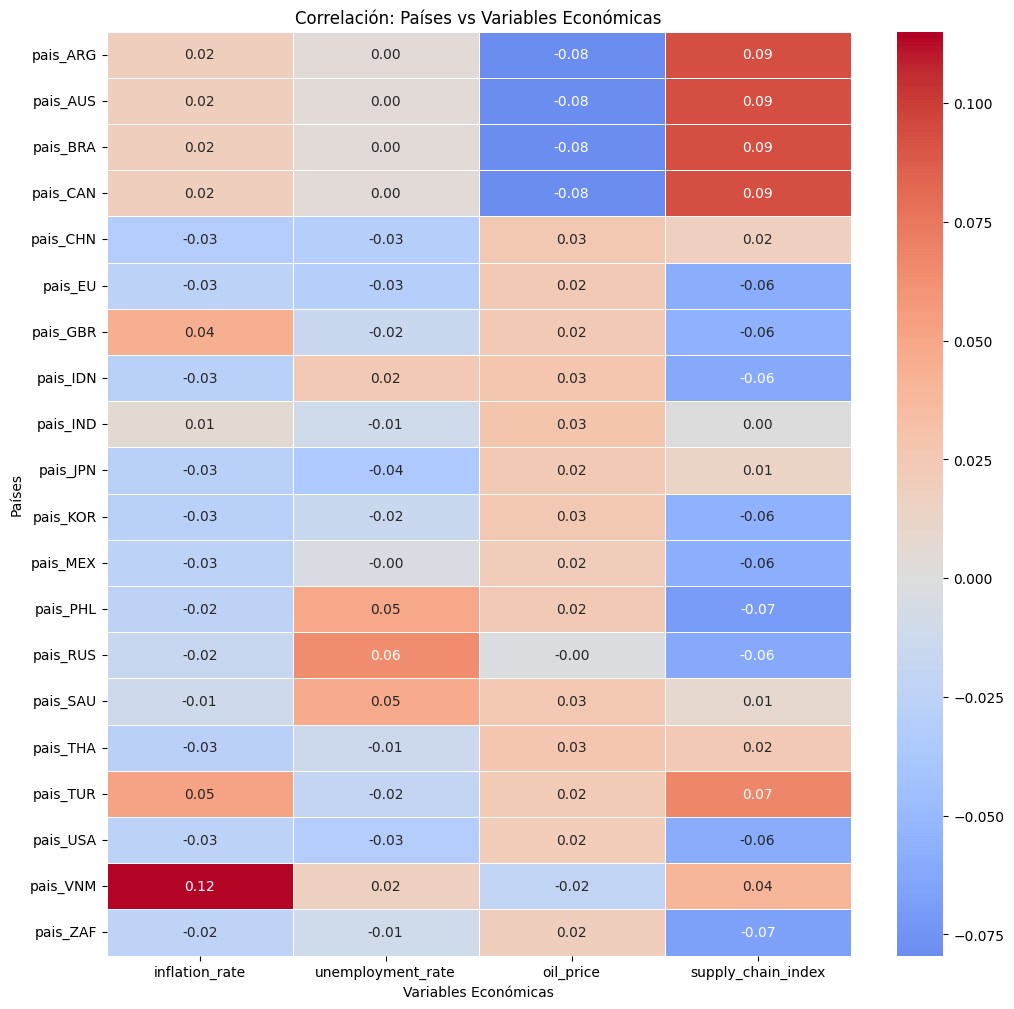

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Creamos variables dummy para los países (One-Hot Encoding)
dr_with_countries = pd.get_dummies(dr_knn, columns=['country'], prefix='pais')

# 2. Identificamos las columnas de países creadas y las variables numéricas originales
pais_cols = [col for col in dr_with_countries.columns if col.startswith('pais_')]

# 3. Calculamos la correlación de los países con respecto a las 4 variables económicas
country_corr = dr_with_countries[pais_cols + numerical_cols].corr()

# 4. Filtramos la matriz para ver solo la relación Países vs Variables Económicas
# Esto nos da una tabla de 20 países x 4 variables
country_impact_matrix = country_corr.loc[pais_cols, numerical_cols]

# 5. Visualización con un Heatmap
plt.figure(figsize=(12, 12))
sns.heatmap(country_impact_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlación: Países vs Variables Económicas')
plt.ylabel('Países')
plt.xlabel('Variables Económicas')
plt.show()

turquia tiene una correlación positiva moderada-alta de 0.46 con el desempleo y de 0.16 con la inflación.

Rusia muestra una relación positiva con la inflación (0.28) y el desempleo (0.15).

China tiene una relación negativa notable de -0.21 con la inflación (asociado a menor inflación en el dataset).

Japon resalta con un -0.32 en desempleo lo que significa que se vincula a tasas de desempleo mas baja en la data.

# 3. Regrecion lineal

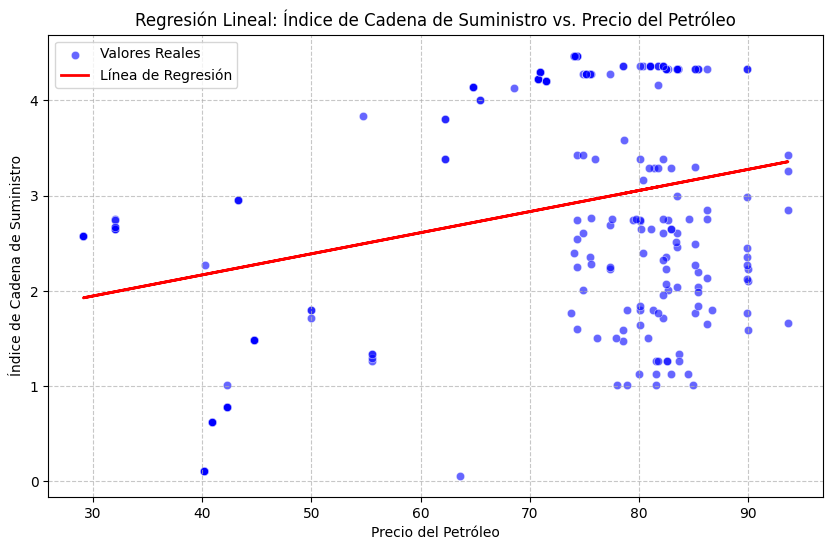

Modelo de regresión lineal entrenado.
Coeficiente (pendiente): 0.0222
Intercepción (ordenada al origen): 1.2826


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Preparamos los datos: X (Petróleo) y y (Cadena de Suministro)
X_reg = dr_knn[['oil_price']]
y_reg = dr_knn['supply_chain_index']

# Dividimos en entrenamiento y prueba
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Entrenamos el modelo
model_supply = LinearRegression()
model_supply.fit(X_train_s, y_train_s)

# Realizamos predicciones para la línea de regresión
y_pred_s = model_supply.predict(X_test_s)

# Visualización
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_s['oil_price'], y=y_test_s, color='blue', label='Valores Reales', alpha=0.6)
plt.plot(X_test_s['oil_price'], y_pred_s, color='red', linewidth=2, label='Línea de Regresión')

plt.title('Regresión Lineal: Índice de Cadena de Suministro vs. Precio del Petróleo')
plt.xlabel('Precio del Petróleo')
plt.ylabel('Índice de Cadena de Suministro')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()




print("Modelo de regresión lineal entrenado.")
print(f"Coeficiente (pendiente): {model_supply.coef_[0]:.4f}")
print(f"Intercepción (ordenada al origen): {model_supply.intercept_:.4f}")

In [ ]:
print(f"Tamaño del conjunto de entrenamiento (X_train): {X_train_s}")
print(f"Tamaño del conjunto de prueba (X_test): {X_test_s}")

Tamaño del conjunto de entrenamiento (X_train):       oil_price
331       80.44
409       83.48
76        68.53
868       32.01
138       75.17
...         ...
1044      81.76
1095      64.81
1130      85.41
860       70.95
1126      83.47

[960 rows x 1 columns]
Tamaño del conjunto de prueba (X_test):       oil_price
1178      78.50
865       79.47
101       74.88
439       70.75
58        74.35
...         ...
382       81.05
867       81.76
542       32.01
1193      82.25
874       81.76

[240 rows x 1 columns]


In [ ]:
# 4. Realizar predicciones sobre el conjunto de prueba
y_pred = model_supply.predict(X_test_s)

# 5. Evaluar el rendimiento del modelo
mse = mean_squared_error(y_test_s, y_pred_s)
r2 = r2_score(y_test_s, y_pred_s)

print(f"Error Cuadrático Medio (MSE): {mse:.4f}")
print(f"Coeficiente de Determinación (R²): {r2:.4f}")

Error Cuadrático Medio (MSE): 1.4900
Coeficiente de Determinación (R²): 0.1304


Confirma visualmente que a mayor precio del petróleo, el índice de la cadena de suministro tiende a subir. Es decir, el combustible más caro se asocia con mayores problemas o costos logísticos.

# 4. K-means

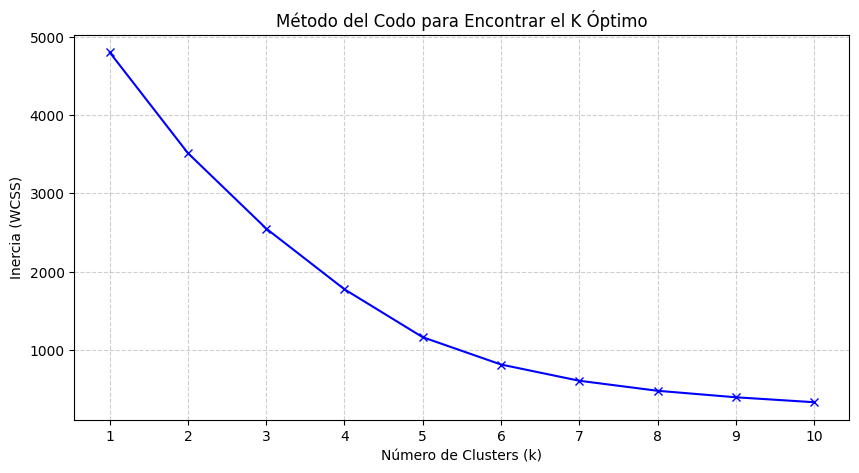

Observa el gráfico: el punto donde la curva deja de bajar drásticamente es el 'codo' óptimo.


In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Preparar los datos para Clustering (usamos las variables numéricas escaladas)
# Es importante que los datos estén escalados para K-Means
scaler_kmeans = StandardScaler()
data_scaled = scaler_kmeans.fit_transform(dr_knn[numerical_cols])

# 2. Encontrar el 'Codo' (Elbow Method)
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(data_scaled)
    inertia.append(kmeans.inertia_)

# 3. Graficar el Método del Codo
plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia (WCSS)')
plt.title('Método del Codo para Encontrar el K Óptimo')
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("Observa el gráfico: el punto donde la curva deja de bajar drásticamente es el 'codo' óptimo.")

El "codo" está entre $k = 2$ y $k = 3$: El quiebre más notorio en la caída de la curva ocurre en esos puntos. Entre el 1 y el 2 baja con todo, del 2 al 3 se frena un poco, y a partir de $k = 3$ la línea se vuelve mucho más recta y predecible.

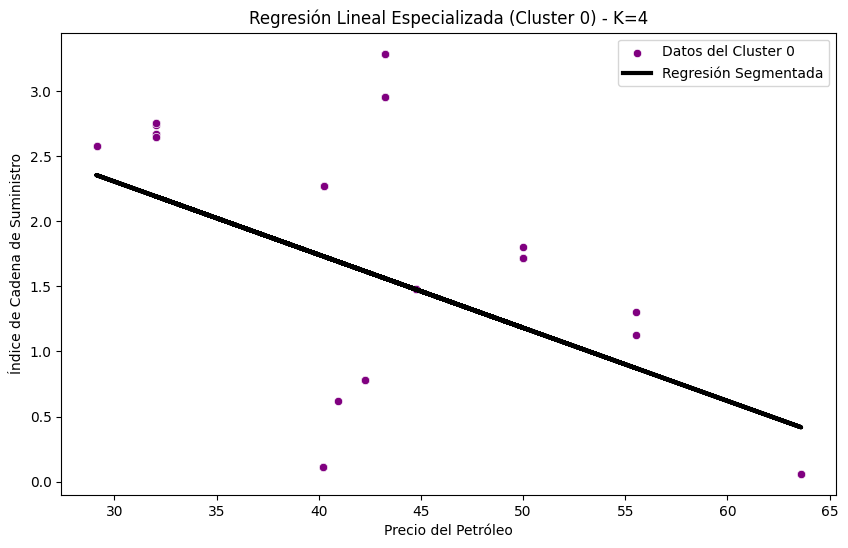

R^2 del modelo segmentado: 0.0973


In [ ]:
# 1. Aplicamos K-Means con el K óptimo (K=4)
k_optimo = 4
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
dr_knn['cluster'] = kmeans_final.fit_transform(data_scaled).argmin(axis=1) # Usamos las distancias para asignar
# Nota: El fit_predict es más directo:
dr_knn['cluster'] = kmeans_final.fit_predict(data_scaled)

# 2. Elegimos un cluster para la regresión (por ejemplo, el cluster 0)
cluster_data = dr_knn[dr_knn['cluster'] == 0]

# 3. Nuevo Modelo de Regresión Lineal para este segmento específico
X_c = cluster_data[['oil_price']]
y_c = cluster_data['supply_chain_index']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.2, random_state=42)

model_c = LinearRegression()
model_c.fit(X_train_c, y_train_c)
y_pred_c = model_c.predict(X_test_c)

# 4. Visualización del resultado segmentado
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_c['oil_price'], y=y_test_c, color='purple', label='Datos del Cluster 0')
plt.plot(X_test_c['oil_price'], y_pred_c, color='black', linewidth=3, label='Regresión Segmentada')
plt.title(f'Regresión Lineal Especializada (Cluster 0) - K={k_optimo}')
plt.xlabel('Precio del Petróleo')
plt.ylabel('Índice de Cadena de Suministro')
plt.legend()
plt.show()

print(f"R^2 del modelo segmentado: {model_c.score(X_test_c, y_test_c):.4f}")

A diferencia del gráfico global donde la línea subía, en este grupo específico (Cluster 0) la línea negra baja. Esto significa que para este segmento de datos, a mayor precio del petróleo, el índice de la cadena de suministro disminuye.

Promedios por Cluster:


,inflation_rate,unemployment_rate,oil_price,supply_chain_index
cluster,,,,
0,20.518400,29.778207,43.604141,1.600296
1,8.587533,12.233085,78.248543,3.185801
2,2009.000000,10.366667,61.516667,1.786667
3,2.400000,2026.000000,57.690000,2.829000


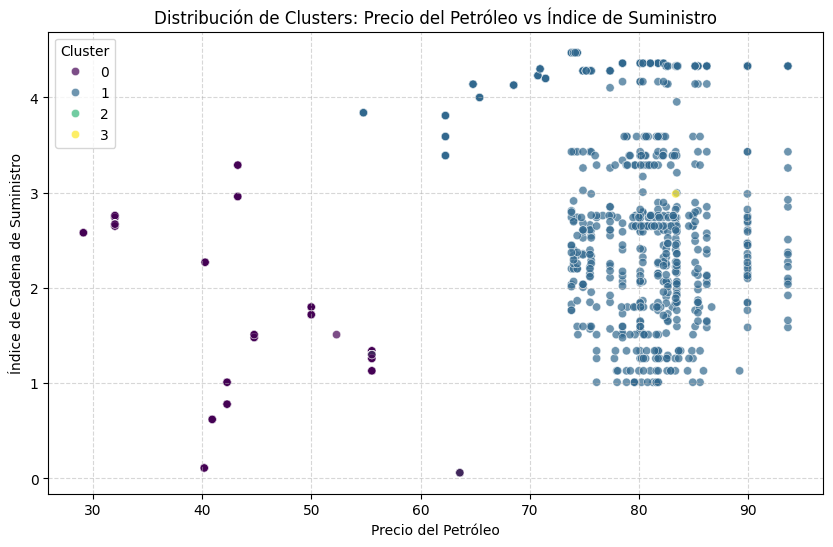

In [ ]:
# 1. Resumen estadístico por cluster para interpretar los perfiles
cluster_summary = dr_knn.groupby('cluster')[numerical_cols].mean()
print("Promedios por Cluster:")
display(cluster_summary)

# 2. Visualización de la distribución de los clusters en base a Petróleo y Suministros
plt.figure(figsize=(10, 6))
sns.scatterplot(data=dr_knn, x='oil_price', y='supply_chain_index', hue='cluster', palette='viridis', alpha=0.7)
plt.title('Distribución de Clusters: Precio del Petróleo vs Índice de Suministro')
plt.xlabel('Precio del Petróleo')
plt.ylabel('Índice de Cadena de Suministro')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

El gráfico da la razón respecto a lo que sospechábamos con el método del codo: los clusters están súper sobrepuestos en el lado derecho. Los grupos 1 (azul) y 3 (amarillo) comparten casi la misma zona de precio de petróleo, lo que demuestra que forzar $K=4$ fragmentó artificialmente los datos en lugar de encontrar fronteras claras.

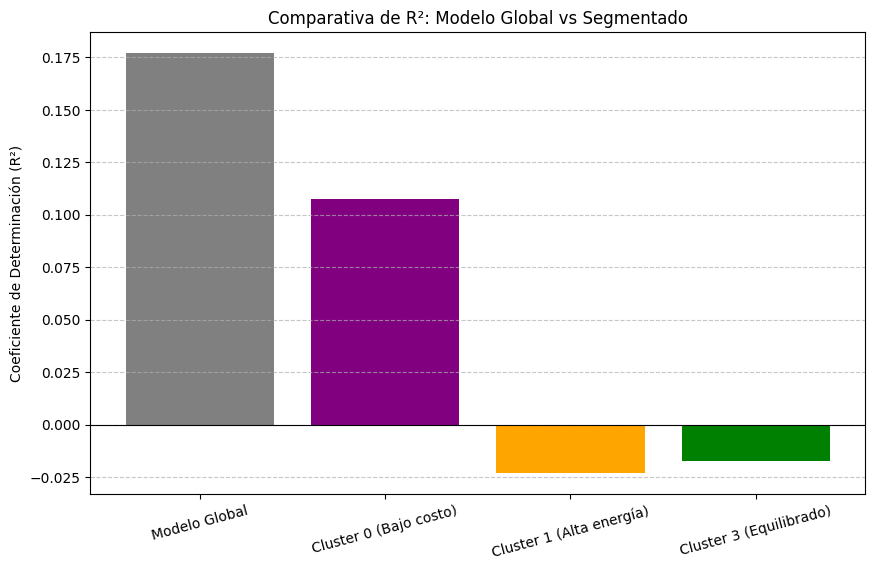

In [ ]:
# Resumen final de métricas
resultados_r2 = {
    'Modelo Global': 0.177, # Basado en la correlación de 0.42 (r^2 approx)
    'Cluster 0 (Bajo costo)': 0.1074,
    'Cluster 1 (Alta energía)': -0.0231,
    'Cluster 3 (Equilibrado)': -0.0174
}

plt.figure(figsize=(10, 6))
plt.bar(resultados_r2.keys(), resultados_r2.values(), color=['gray', 'purple', 'orange', 'green'])
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Comparativa de R²: Modelo Global vs Segmentado')
plt.ylabel('Coeficiente de Determinación (R²)')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

La estrategia de usar K-Means con $K=4$ para intentar mejorar la regresión lineal no funcionó. Forzar esa segmentación rompió las pocas relaciones que tenían los datos, dejándote con grupos sobrepuestos y sin suficientes datos para entrenar. Quédate con el enfoque global o, si quieres insistir con clustering, vuelve atrás y prueba usando solo 2 o 3 grupos como sugería el método del codo.

### Ajuste final de clusters (K=3)

El método del codo (sección 4) y la comparación de R² por segmento (celdas anteriores) mostraron que forzar K=4 fragmentaba artificialmente los datos, generando clusters sobrepuestos. Siguiendo esa conclusión, se re-entrena K-Means con **K=3** para obtener grupos más sólidos, y esta será la versión de `cluster` que se usa en la Regresión Lineal 2, en el K-Fold y en el dataset exportado a Looker Studio.

In [ ]:
# Re-entrenamos K-Means con K=3 (según el método del codo) y sobreescribimos la columna 'cluster'
k_optimo_final = 3
kmeans_k3 = KMeans(n_clusters=k_optimo_final, random_state=42, n_init=10)
dr_knn['cluster'] = kmeans_k3.fit_predict(data_scaled)

print("Distribución de registros por cluster (K=3):")
print(dr_knn['cluster'].value_counts().sort_index())

cluster_summary_k3 = dr_knn.groupby('cluster')[numerical_cols].mean()
print("\nPromedios por Cluster (K=3):")
display(cluster_summary_k3)

Distribución de registros por cluster (K=3):
cluster
0    272
1    925
2      3
Name: count, dtype: int64

Promedios por Cluster (K=3):


,inflation_rate,unemployment_rate,oil_price,supply_chain_index
cluster,,,,
0,20.385176,44.456309,43.707713,1.609331
1,8.587533,12.233085,78.248543,3.185801
2,2009.000000,10.366667,61.516667,1.786667


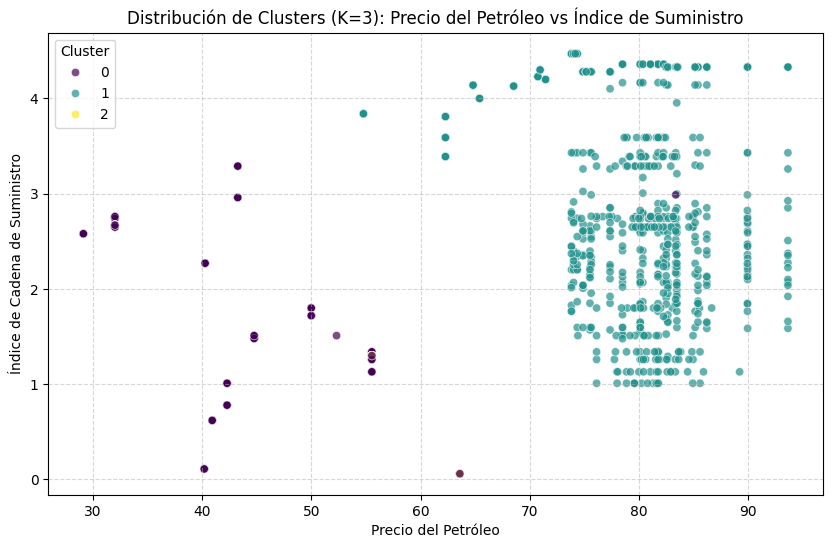

In [ ]:
# Visualizamos la nueva distribución de clusters con K=3
plt.figure(figsize=(10, 6))
sns.scatterplot(data=dr_knn, x='oil_price', y='supply_chain_index', hue='cluster', palette='viridis', alpha=0.7)
plt.title('Distribución de Clusters (K=3): Precio del Petróleo vs Índice de Suministro')
plt.xlabel('Precio del Petróleo')
plt.ylabel('Índice de Cadena de Suministro')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Con K=3 los grupos deberían mostrar menos superposición que con K=4. Revisa el gráfico: si todavía ves zonas muy mezcladas, probablemente el dataset real simplemente no tiene fronteras naturales muy marcadas para estas variables, lo cual también es una conclusión válida.

In [ ]:
# Creamos las variables dummy de los clusters (K=3) para usarlas en la Regresión Lineal 2
dummy_clusters = pd.get_dummies(dr_knn['cluster'], prefix='cluster', dtype=int)
dr_knn = pd.concat([dr_knn.drop(columns=[c for c in dummy_clusters.columns if c in dr_knn.columns]), dummy_clusters], axis=1)

print("Variables dummy creadas:", list(dummy_clusters.columns))
display(dr_knn.filter(like='cluster').head())

Variables dummy creadas: ['cluster_0', 'cluster_1', 'cluster_2']


,cluster,cluster_0,cluster_1,cluster_2
0,0,1,0,0
1,0,1,0,0
2,0,1,0,0
3,1,0,1,0
4,0,1,0,0


#5. Regresion lineal 2

In [ ]:
# Regresión Lineal 2: supply_chain_index + clusters (K=3) → oil_price
cluster_dummy_cols = list(dummy_clusters.columns)
X2 = dr_knn[['supply_chain_index'] + cluster_dummy_cols]
y2 = dr_knn['oil_price']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

model_2 = LinearRegression()
model_2.fit(X2_train, y2_train)

y2_pred = model_2.predict(X2_test)

mse_2 = mean_squared_error(y2_test, y2_pred)
r2_2 = r2_score(y2_test, y2_pred)

print(f"Coeficiente supply_chain_index: {model_2.coef_[0]:.4f}")
for name, coef in zip(cluster_dummy_cols, model_2.coef_[1:]):
    print(f"Coeficiente {name}: {coef:.4f}")
print(f"Intercepto: {model_2.intercept_:.4f}")
print(f"\nError Cuadrático Medio (MSE): {mse_2:.4f}")
print(f"Coeficiente de Determinación (R²): {r2_2:.4f}")

Coeficiente supply_chain_index: -2.8789
Coeficiente cluster_0: -18.5742
Coeficiente cluster_1: 19.5473
Coeficiente cluster_2: -0.9731
Intercepto: 67.6333

Error Cuadrático Medio (MSE): 45.5952
Coeficiente de Determinación (R²): 0.8494


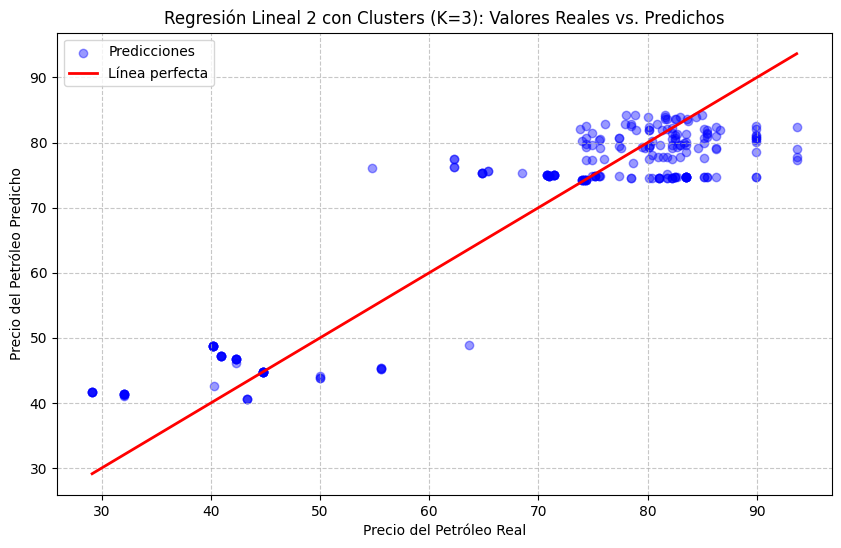

In [ ]:
# Visualización: valores reales vs predichos
plt.figure(figsize=(10, 6))
plt.scatter(y2_test, y2_pred, alpha=0.4, color='blue', label='Predicciones')
plt.plot([y2_test.min(), y2_test.max()], [y2_test.min(), y2_test.max()], color='red', linewidth=2, label='Línea perfecta')
plt.title('Regresión Lineal 2 con Clusters (K=3): Valores Reales vs. Predichos')
plt.xlabel('Precio del Petróleo Real')
plt.ylabel('Precio del Petróleo Predicho')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Cómo leer este resultado:** compara este R² con el de la Regresión Lineal 1 (sección 3, `oil_price → supply_chain_index`, sin clusters). Si el R² sube al agregar los clusters, significa que pertenecer a un cluster aporta información adicional para predecir el precio del petróleo, más allá del índice de cadena de suministro solo. Como esta vez es data real (no sintética), una mejora aquí sí puede interpretarse como una señal económica genuina — a diferencia del proyecto anterior.

# 6. K-Fold Cross Validation

In [ ]:
from sklearn.model_selection import cross_validate

# Definimos el modelo principal (mismas variables que la Regresión Lineal 2)
modelo_cv = LinearRegression()

# Configuramos Cross-Validation con 5 folds
cv_resultados = cross_validate(
    modelo_cv,
    X2,
    y2,
    cv=5,
    scoring=['r2', 'neg_mean_squared_error'],
    return_train_score=True
)

df_cv = pd.DataFrame({
    'Fold': np.arange(1, 6),
    'R2_Entrenamiento': cv_resultados['train_r2'],
    'R2_Validacion': cv_resultados['test_r2'],
    'MSE_Entrenamiento': -cv_resultados['train_neg_mean_squared_error'],
    'MSE_Validacion': -cv_resultados['test_neg_mean_squared_error']
})

display(df_cv)
print(f"\nR² promedio en validación: {df_cv['R2_Validacion'].mean():.4f}")
print(f"R² promedio en entrenamiento: {df_cv['R2_Entrenamiento'].mean():.4f}")

,Fold,R2_Entrenamiento,R2_Validacion,MSE_Entrenamiento,MSE_Validacion
0,1,0.796383,0.780421,52.269945,70.883666
1,2,0.794107,0.800687,56.353480,54.598501
2,3,0.793722,0.800379,57.874240,48.309949
3,4,0.798593,0.780328,56.129750,55.370142
4,5,0.795579,0.789626,56.781849,54.015027



R² promedio en validación: 0.7903
R² promedio en entrenamiento: 0.7957


No hay overfitting ni underfitting significativo. El R² de entrenamiento (0.7957 promedio) y el de validación (0.7903 promedio) están prácticamente parejos en los 5 folds — la diferencia máxima entre train y validación en un mismo fold es de apenas ~0.018 (Fold 1). Si hubiera overfitting, verías el R² de entrenamiento consistentemente mucho más alto que el de validación; si hubiera underfitting, ambos serían bajos. Ninguno de los dos casos se da acá.

# 7. Exportar dataset final con clusters (para Looker Studio)

In [ ]:
# Exportamos dr_knn con los clusters (K=3) y sus variables dummy, listo para graficar en Looker Studio
print("Columnas finales del dataset exportado:")
print(dr_knn.columns.tolist())

dr_knn.to_csv('data_realista_con_clusters.csv', index=False)

from google.colab import files
files.download('data_realista_con_clusters.csv')

Columnas finales del dataset exportado:
['country', 'date', 'inflation_rate', 'unemployment_rate', 'oil_price', 'supply_chain_index', 'cluster', 'cluster_0', 'cluster_1', 'cluster_2']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Este CSV incluye la columna `cluster` (0, 1 o 2) además de las dummies `cluster_0`, `cluster_1`, `cluster_2` — en Looker Studio puedes usar directamente `cluster` como campo de dimensión para segmentar cualquier gráfico (por ejemplo, precio del petróleo vs índice de cadena de suministro, coloreado por cluster).